# Garden map.

Installation:
- Install geopandas using `pip install geopandas contextily`
- Downgrade fiona using `pip install fiona==1.9.6`

See [this post](https://stackoverflow.com/questions/78949093/how-to-resolve-attributeerror-module-fiona-has-no-attribute-path) for the reason. 

#### Permapeople 
https://permapeople.org/my/api_keys
id	5CbMcxq8EnrG	

In [ ]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import geopandas as gpd
from python import geo_parsers, garden_elements, field_parsers, ranging_correction, garden_model_plots
from python import gtsam_position_refinement as gtsam_refine
import contextily as cx
from shapely.geometry import Point

from plotting import plot_annotation as plots

crs  WGS84


## Get kadaster coordinates

Use data downloaded from pdoc.

Get:
- `db_info_percelen` List with properties of each kadaster entry. Only geometry is the midpoint of each kadaster entry.
- `gdf` List with geometries (outlines) of each kadaster field.

Both are converted to crs of choice, default Amersfoort EPSG:28992.

[soort grootte](http://brk.basisregistraties.overheid.nl/id/concept/SoortGrootte): of het vastegesteld is of niet.

In [3]:
# Get list of kadaser objects with generic properies and center point.
db_info_percelen = geo_parsers.get_kadaster_objects(kadastrale_object_ids=geo_parsers.kadastrale_object_ids_own,
                                                file_path = geo_parsers.DATASETS / "kadastralekaart_perceel.gml")

In [4]:
# Kadaster contours.
gdf_kadaster = [geo_parsers.get_perceel_coordinates(id, as_polygon=False, file_path= geo_parsers.DATASETS / "kadastralekaart_kadastralegrens.gml",) for id in db_info_percelen.index]
gdf_kadaster = gpd.GeoDataFrame( pd.concat( gdf_kadaster, ignore_index=False) )
p_origin = geo_parsers.get_lower_left_point_in_veelerveen_rotation(gdf_kadaster) # Geoseries.

EPSG:28992


## Change to 'Veelerveen coordinates'.
Origin at lower left hand corner, in meters, such that the north side of the land border is horizontal.

In [5]:
# Create Veelerveen crs
lat_min = p_origin.to_crs('WGS84').get_coordinates().y.min()
lon_min = p_origin.to_crs('WGS84').get_coordinates().x.min()
crs_veelerveen = geo_parsers.get_crs_veeleerveen(lat_min, lon_min)

In [6]:
# Convert both kadaster outlines and kadaset database to veelerveen coordinates.
gdf_kadaster = gdf_kadaster.to_crs(crs_veelerveen)
db_info_percelen = db_info_percelen.to_crs(crs_veelerveen)

## Add trees and ditches.

In [7]:
# Define origin of orchard as interesting point.
p_origin_orchard = geo_parsers.get_lower_left_point_in_veelerveen_rotation(gdf_kadaster).get_coordinates().iloc[0].values + np.asarray([74, 2])
p_origin_orchard = gpd.GeoSeries(data=Point(*p_origin_orchard), index=['origin_orchard'], crs=crs_veelerveen)

+proj=omerc +lat_0=53.057737974045686 +lonc=7.120513314950776 +alpha=-21 +k=1 +x_0=0 +y_0=0 +gamma=0 +ellps=WGS84 +towgs84=0,0,0,0,0,0,0 +type=crs


In [8]:
gdf_ditch = garden_elements.get_veelerveen_ditches()

In [9]:
# GPS scan of trees.
gdf_trees = field_parsers.read_gps_coordinates_recorded_with_app(fname = geo_parsers.DATASETS / "boomgaard_plant_coordinaten/20251005-091825.kml", 
                                                                 crs_veelerveen=crs_veelerveen)

gdf_trees = field_parsers.add_row_to_tree_list(gdf_trees, kind='Corner', new_id=None, base_id=5, replace=True)
gdf_trees = field_parsers.add_row_to_tree_list(gdf_trees, kind='Tamme kastagne', px=110, new_id=None, base_id=15, replace=False)


gdf_trees['label'] = gdf_trees.apply(lambda row: f'{row.name}_{row.kind}', axis=1)
gdf_trees['n_corrections'] = 0

gdf_trees = field_parsers.add_row_to_tree_list(gdf_trees,
                                  kind="Corner", px=76.0, py=22, new_id=5, base_id=5)
gdf_trees


Wrote 19 tree entries to /home/henk/Code/garden_dynamics/datasets/examples_gdf_trees.toml


,id,kind,description,geometry,label,n_corrections
0,3,Corner,None,POINT Z (75.714 3.8 44.669),0_Corner,0
1,4,Wilg,None,POINT Z (81.866 5.757 43.57),1_Wilg,0
2,5,Wilg,None,POINT Z (80.858 10.782 43.231),2_Wilg,0
3,6,Wilg,None,POINT Z (81.387 14.67 43.239),3_Wilg,0
4,7,Wilg,None,POINT Z (81.117 19.882 42.943),4_Wilg,0
5,8,Corner,None,POINT (76 22),5_Corner,0
6,10,Fruit,None,POINT Z (84.223 17.943 43.101),6_Fruit,0
7,11,Fruit,None,POINT Z (83.583 13.57 43.671),7_Fruit,0
8,12,Hole,None,POINT Z (87.143 13.163 45.46),8_Hole,0
9,13,Appelboom,None,POINT Z (88.328 14.705 45.271),9_Appelboom,0


## Plotting

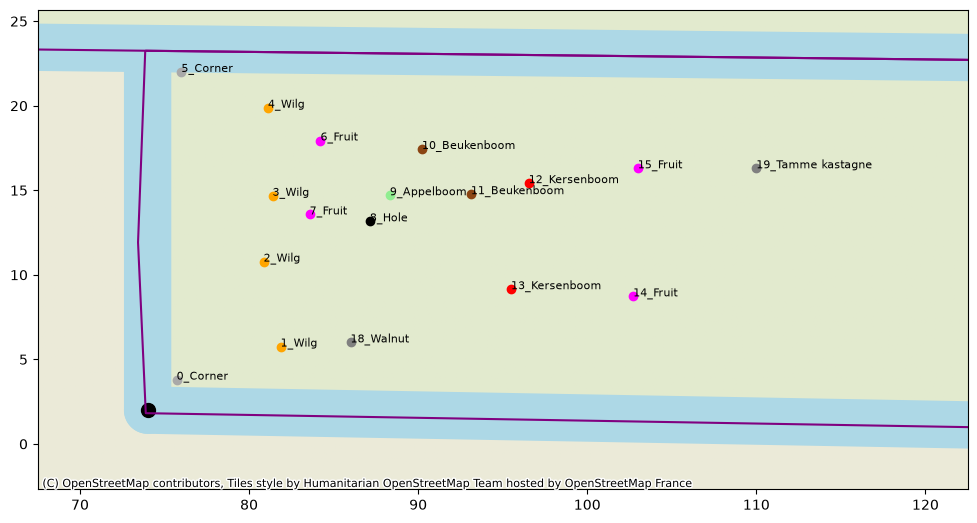

In [10]:
def plot_trees(ax, gdf_trees, row_label='label'):

    for label, df_group in gdf_trees.groupby('kind'):
        color = garden_elements.element_colors.get(label, 'grey')
        df_group.plot(ax=ax, color=color)
    geo_parsers.add_label_annotation_to_map(ax, gdf_trees, fontweight='normal', fontsize=8, horizontalalignment='left', row_label=row_label)
    return ax

def plot_orchard(gdf_kadaster, db_info_percelen, gdf_trees, tree_label_column='label', add_basemap=True):
    _, ax = plt.subplots(1,1, figsize=(12, 8), squeeze=True)

    gdf_north = geo_parsers.get_north_arrow(crs_veelerveen, p_shift_x=0, p_shift_y=0)
    gdf_north.plot(ax=ax, linewidth=4, color='k')

    ax = gdf_kadaster.plot(color='purple', edgecolor="black", alpha=1, ax=ax)
    ax = db_info_percelen.plot(color='orange', edgecolor="black", alpha=1, ax=ax, markersize=30)
    if add_basemap:
        cx.add_basemap(ax, crs=gdf_kadaster.crs, alpha=.6)
    geo_parsers.add_label_annotation_to_map(ax, db_info_percelen)

    gdf_ditch.plot(ax=ax, color='lightblue')

    p_origin.to_crs(crs_veelerveen).plot(ax=ax, color='black', markersize=100)

    plot_trees(ax, gdf_trees, row_label=tree_label_column)

    p_origin_orchard.plot(ax=ax, color='black', markersize=100)
    ax.set_ylim(-2, 25)
    # ax.set_xlim(70, 180)
    ax.set_xlim(70, 120)
    ax.set_aspect('equal')

    garden_elements.widen_map_plot(ax, percentage_x=0.1, percentage_y=0.051)
    return ax

ax = plot_orchard(gdf_kadaster, db_info_percelen, gdf_trees)

# Refine the positions
$J(x_0) = \begin{bmatrix} 2r_0^\top & -2r_0^\top \end{bmatrix} \in \mathbb{R}^{1\times 4}$


In [ ]:
measurements = ranging_correction.measurements

: 

In [ ]:
ax = plot_orchard(gdf_kadaster, db_info_percelen, gdf_trees, add_basemap=False)

# Build and solve a batch GTSAM factor graph.
gtsam_refine.validate_inputs(
    gdf_trees,
    measurements,
    hard_anchor_id=0,
    soft_anchor_id=5,
 )

graph, initial_values, state_indices = gtsam_refine.build_initial_values_and_priors(
    gdf_trees,
    sigma_gps=4.0,
    sigma_corner=0.1,
    hard_anchor_id=0,
    soft_anchor_id=5,
    hard_anchor_sigma=1e-3,
 )
graph = gtsam_refine.add_range_factors(graph, measurements)

result_values = gtsam_refine.solve_batch(
    graph,
    initial_values,
    max_iterations=200,
 )

gdf_trees_corrected = gtsam_refine.apply_solution_to_gdf(gdf_trees, result_values)
plot_trees(ax, gdf_trees_corrected, row_label='n_corrections')

# Diagnostics similar to the previous df_correction table.
df_correction = gtsam_refine.build_distance_diagnostics(
    gdf_before=gdf_trees,
    gdf_after=gdf_trees_corrected,
    measurements=measurements,
 )


In [ ]:

gdf_trees_corrected_regular = field_parsers.gdf_trees_to_regular_pandas(gdf_trees_corrected)

for _, d_correction in df_correction.iterrows():
    i_A = int(d_correction['i_A'])
    i_B = int(d_correction['i_B'])
    p_A = np.asarray(gdf_trees_corrected_regular.loc[i_A][['px', 'py']], dtype=float)
    p_B = np.asarray(gdf_trees_corrected_regular.loc[i_B][['px', 'py']], dtype=float)
    delta = d_correction.residual_post
    s = f'{delta:.1f}'
    garden_model_plots.draw_annotated_arrow(ax, p_A, p_B, s=s, color='red', linewidth=1, alpha=0.5)

df_correction

In [ ]:
d_correction

In [ ]:
import sys
print(sys.executable)
try:
    import gtsam
    print('gtsam import OK')
    print(getattr(gtsam, '__version__', 'no __version__ attribute'))
except Exception as e:
    print(type(e).__name__, str(e))

/home/henk/Code/garden_dynamics/.venv/bin/python
gtsam import OK
no __version__ attribute
